<h1> Insurance notebook </h2>

In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('insurance.csv')
df= pd.DataFrame(data)
data.head()

,age,sex,bmi,children,smoker,region,charges,Unnamed: 7,Unnamed: 8,charges.1
0,19,female,27.900,0.000,yes,southwest,16884.920,NaN,NaN,16884.920
1,18,male,33.770,1.000,no,southeast,1725.550,NaN,NaN,1725.550
2,28,male,33.000,3.000,no,southeast,4449.460,NaN,NaN,4449.460
3,33,male,22.705,0.000,no,northwest,21984.470,NaN,NaN,21984.470
4,32,male,28.880,0.000,no,northwest,3866.860,NaN,NaN,3866.860


#Removing duplicates

In [21]:
df_unique_names = df.drop_duplicates(subset=['charges'], keep='first')

#Check null values

In [22]:
df.isnull().any()

age           True
sex           True
bmi           True
children      True
smoker        True
region        True
charges       True
Unnamed: 7    True
Unnamed: 8    True
charges.1     True
dtype: bool

#Check datatype

In [23]:
df.dtypes 

age            object
sex            object
bmi           float64
children      float64
smoker         object
region         object
charges       float64
Unnamed: 7    float64
Unnamed: 8    float64
charges.1     float64
dtype: object

In [24]:
import numpy as np

arr = np.array([16884.92400, 1725.55230])
np.set_printoptions(precision=4)
print(arr)   # [1.2346 2.3457]

[16884.924   1725.5523]


In [29]:
pd.options.display.float_format = "{:.3f}".format

print(df)
 

     age   sex    bmi  children smoker     region   charges  Unnamed: 7  \
0     19 0.000 27.900     0.000    yes  southwest 16884.920         NaN   
1     18 1.000 33.770     1.000     no  southeast  1725.550         NaN   
2     28 1.000 33.000     3.000     no  southeast  4449.460         NaN   
3     33 1.000 22.705     0.000     no  northwest 21984.470         NaN   
4     32 1.000 28.880     0.000     no  northwest  3866.860         NaN   
...   ..   ...    ...       ...    ...        ...       ...         ...   
2671  50   NaN    NaN       NaN    NaN        NaN       NaN         NaN   
2672  18   NaN    NaN       NaN    NaN        NaN       NaN         NaN   
2673  18   NaN    NaN       NaN    NaN        NaN       NaN         NaN   
2674  21   NaN    NaN       NaN    NaN        NaN       NaN         NaN   
2675  61   NaN    NaN       NaN    NaN        NaN       NaN         NaN   

      Unnamed: 8  charges.1  
0            NaN  16884.920  
1            NaN   1725.550  
2        

#Assigning variables to age and charges

In [25]:
# Assigning variables 
X = df[['age']]  
# Target 
Y = df[['charges']]  

#Spliting the data

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [58]:
print(X_train.dtypes)
print(Y_train.dtypes)


age    int64
dtype: object
charges    float64
dtype: object


#Converting float to int

In [28]:
df[['charges']] = df[['charges']].astype(int)

print(df.dtypes)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

#Removing spaces inbetween data points

In [61]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['charges'] = pd.to_numeric(df['charges'], errors='coerce')


In [62]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884
1,18,male,33.770,1,no,southeast,1725
2,28,male,33.000,3,no,southeast,4449
3,33,male,22.705,0,no,northwest,21984
4,32,male,28.880,0,no,northwest,3866
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600
1333,18,female,31.920,0,no,northeast,2205
1334,18,female,36.850,0,no,southeast,1629
1335,21,female,25.800,0,no,southwest,2007


In [27]:
df.smoker.unique()

array(['yes', 'no', nan], dtype=object)

In [26]:
df['sex'] = df['sex'].map({'male':1, 'female':0})
df.head()

,age,sex,bmi,children,smoker,region,charges,Unnamed: 7,Unnamed: 8,charges.1
0,19,0.000,27.900,0.000,yes,southwest,16884.920,NaN,NaN,16884.920
1,18,1.000,33.770,1.000,no,southeast,1725.550,NaN,NaN,1725.550
2,28,1.000,33.000,3.000,no,southeast,4449.460,NaN,NaN,4449.460
3,33,1.000,22.705,0.000,no,northwest,21984.470,NaN,NaN,21984.470
4,32,1.000,28.880,0.000,no,northwest,3866.860,NaN,NaN,3866.860


In [31]:
cols=['Unnamed:7',
      'Unnamed:8',
      
      ]
df=df.drop(cols,axis=1)

KeyError: "['Unnamed:7', 'Unnamed:8'] not found in axis"

#Data visualisation

In [19]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),annot=True)

ValueError: could not convert string to float: '19,18,28,33,32,31,46,37,37,60,25,62,23,56,27,19,52,23,56,30,60,30,18,34,37,59,63,55,23,31,22,18,19,63,28,19,62,26,35,60,24,31,41,37,38,55,18,28,60,36,18,21,48,36,40,58,58,18,53,34,43,25,64,28,20,19,61,40,40,28,27,31,53,58,44,57,29,21,22,41,31,45,22,48,37,45,57,56,46,55,21,53,59,35,64,28,54,55,56,38,41,30,18,61,34,20,19,26,29,63,54,55,37,21,52,60,58,29,49,37,44,18,20,44,47,26,19,52,32,38,59,61,53,19,20,22,19,22,54,22,34,26,34,29,30,29,46,51,53,19,35,48,32,42,40,44,48,18,30,50,42,18,54,32,37,47,20,32,19,27,63,49,18,35,24,63,38,54,46,41,58,18,22,44,44,36,26,30,41,29,61,36,25,56,18,19,39,45,51,64,19,48,60,27,46,28,59,35,63,40,20,40,24,34,45,41,53,27,26,24,34,53,32,19,42,55,28,58,41,47,42,59,19,59,39,40,18,31,19,44,23,33,55,40,63,54,60,24,19,29,18,63,54,27,50,55,56,38,51,19,58,20,52,19,53,46,40,59,45,49,18,50,41,50,25,47,19,22,59,51,40,54,30,55,52,46,46,63,59,52,28,29,25,22,25,18,19,47,31,48,36,53,56,28,57,29,28,30,58,41,50,19,43,49,27,52,50,5

<Figure size 2000x2000 with 0 Axes>

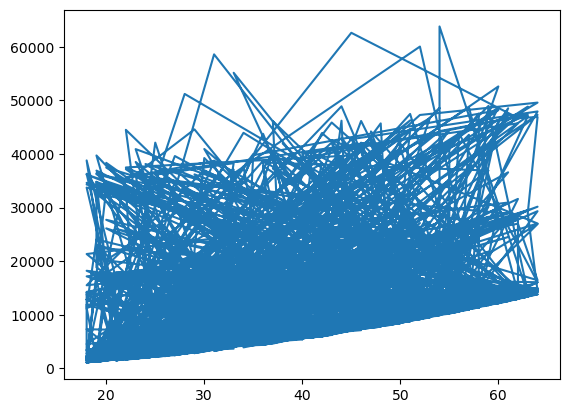

In [ ]:
plt.plot(X,Y)
plt.show()

#Bargraph

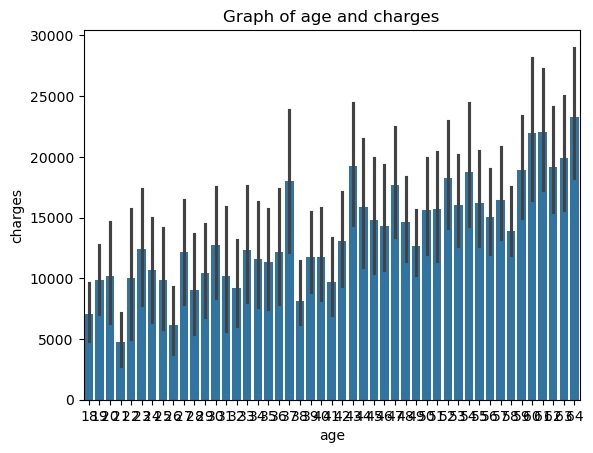

In [27]:
sns.barplot(x='age',y='charges', data=data)
plt.title('Graph of age and charges')
plt.show()

#Fit the model

In [ ]:
model = LinearRegression()
model.fit(X, Y)
print(model)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(model.get_params())


LinearRegression()
Coefficients: [[257.22971643]]
Intercept: [3190.02191503]
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


#Visualizing the model

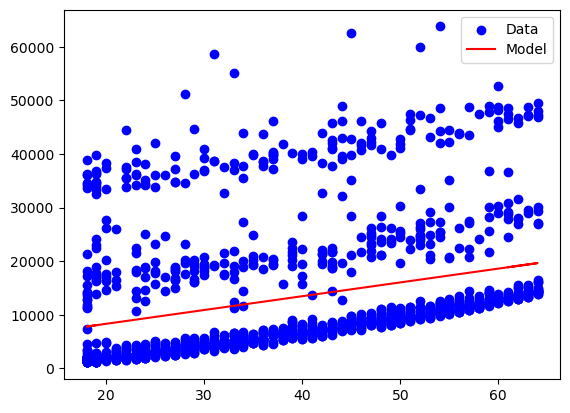

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, color="blue", label="Data")
plt.plot(X, model.predict(X), color="red", label="Model")
plt.legend()
plt.show()


In [33]:
model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
print(X_test)


      age  bmi  children
899    49   22         0
1063   29   25         4
1255   51   36         3
298    31   34         3
237    31   38         2
...   ...  ...       ...
534    64   40         0
542    63   36         0
759    22   34         2
1283   61   36         1
1284   47   24         0

[268 rows x 3 columns]


In [64]:
print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("R² Score:", r2_score(Y_test, Y_pred))



NameError: name 'Y_pred' is not defined

In [25]:
model = LinearRegression()
model.fit(X_train, Y_train)
print(model)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(model.get_params())

LinearRegression()
Coefficients: [[224.33651461 277.29068558 692.31531459]]
Intercept: [-4845.96162087]
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       1337 non-null   int64 
 1   sex       1337 non-null   object
 2   bmi       1337 non-null   int64 
 3   children  1337 non-null   int64 
 4   smoker    1337 non-null   object
 5   region    1337 non-null   object
 6   charges   1337 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 73.2+ KB


#Statistic info

In [8]:
df.describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.122
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.870
25%,27.000,26.290,0.000,4746.340
50%,39.000,30.400,1.000,9386.160
75%,51.000,34.700,2.000,16657.720
max,64.000,53.130,5.000,63770.430


#Visualizing plots

Text(0.5, 1.0, 'Plots showing the relatioship between different parameters')

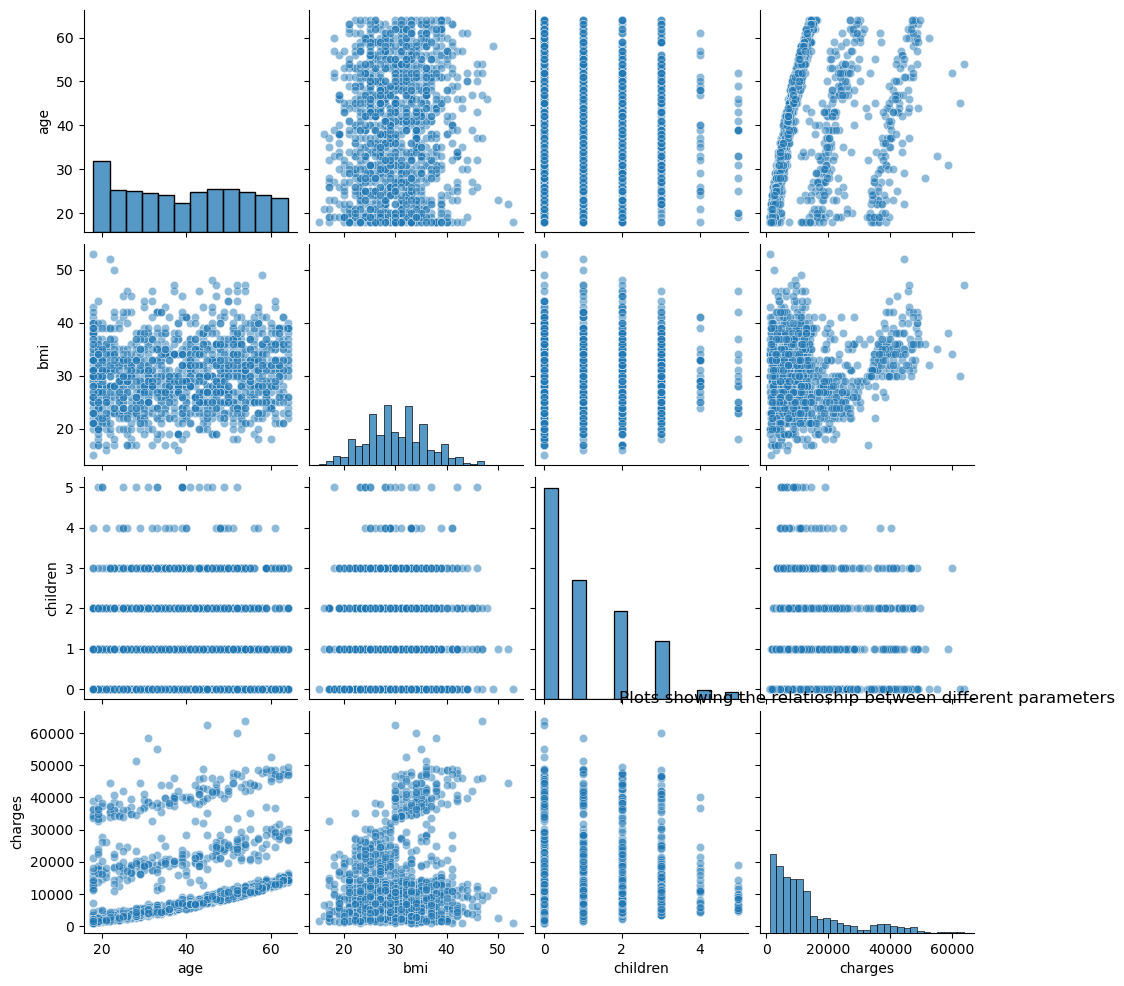

In [32]:
sns.pairplot(df, kind= 'scatter', plot_kws={"alpha":0.5})
plt.title('Plots showing the relatioship between different parameters')

In [19]:
# Features (must be 2D for scikit-learn)
X = df[['age', 'bmi', 'children']]  
# Target 
y = df[['charges']]  

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
df[['charges']] = df[['charges']].astype(int)
df[['bmi']] = df[['bmi']].astype(int)
print(df.dtypes)

age          int64
sex         object
bmi          int64
children     int64
smoker      object
region      object
charges      int64
dtype: object


In [22]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['charges'] = pd.to_numeric(df['charges'], errors='coerce')
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['children'] = pd.to_numeric(df['children'], errors='coerce')

In [14]:
# Identify categorical columns
categorical_cols = ['sex', 'region']
numeric_cols = ['charges']

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)
print(model)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(model.get_params())

LinearRegression()
Coefficients: [[224.33718265 277.2922055  692.32548857]]
Intercept: [-4846.53146751]
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [23]:
model = LinearRegression()
model.fit(X, y)
print(model)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(model.get_params())

LinearRegression()
Coefficients: [[239.81645528 327.30908204 542.49747845]]
Intercept: [-6596.75928402]
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [34]:
# Predict on test data
predictions = model.predict(X_test)

# Display results
print("Predictions:", predictions)
print("Actual:", y_test.values)


Predictions: [[12246.92267763]
 [11361.32570061]
 [18654.61124874]
 [13613.29958545]
 [14030.14701319]
 [17790.91359052]
 [11680.87352517]
 [ 6744.41815442]
 [15197.99781713]
 [15987.61273489]
 [14661.67016732]
 [14306.38564935]
 [12175.7147853 ]
 [21039.35593568]
 [14927.49307161]
 [14397.95136187]
 [ 9483.67661002]
 [13627.64221489]
 [ 8749.10415644]
 [10393.54249916]
 [ 8791.36129543]
 [11686.60741582]
 [19177.36701843]
 [12359.61695964]
 [12262.31735647]
 [10400.32843922]
 [17052.43004502]
 [17487.53119411]
 [15157.56347686]
 [18396.62633394]
 [10704.48158494]
 [17322.93479054]
 [ 6262.096725  ]
 [16569.05656619]
 [20300.87239018]
 [16715.3992484 ]
 [10642.14792588]
 [ 9229.60278714]
 [12589.68736489]
 [13929.97256188]
 [10903.77843813]
 [11730.95284801]
 [16582.62844631]
 [16160.81787724]
 [12126.67170625]
 [ 8367.72792763]
 [10283.72306528]
 [13534.25370365]
 [ 9060.04324223]
 [14161.09501655]
 [11970.68404146]
 [15549.37124318]
 [12425.09096132]
 [ 8791.36129543]
 [15665.9766171

#Removing Outliers

In [50]:
max_thresold=df['age'].quantile(0.95)
max_thresold
max_thresold=df['charges'].quantile(0.05)
max_thresold
print(df)

      age     sex  bmi  children smoker     region  charges
0      19  female   27         0    yes  southwest    16884
1      18    male   33         1     no  southeast     1725
2      28    male   33         3     no  southeast     4449
3      33    male   22         0     no  northwest    21984
4      32    male   28         0     no  northwest     3866
...   ...     ...  ...       ...    ...        ...      ...
1332   50    male   30         3     no  northwest    10600
1333   18  female   31         0     no  northeast     2205
1334   18  female   36         0     no  southeast     1629
1335   21  female   25         0     no  southwest     2007
1336   61  female   29         0    yes  northwest    29141

[1337 rows x 7 columns]


In [57]:
df[df['age']>max_thresold]
max_thresold
df[df['charges']>max_thresold]
max_thresold

np.float64(1767.0)

In [55]:
min_thresold=df['age'].quantile(0.95)
min_thresold
min_thresold=df['charges'].quantile(0.05)
min_thresold
print(df)

      age     sex  bmi  children smoker     region  charges
0      19  female   27         0    yes  southwest    16884
1      18    male   33         1     no  southeast     1725
2      28    male   33         3     no  southeast     4449
3      33    male   22         0     no  northwest    21984
4      32    male   28         0     no  northwest     3866
...   ...     ...  ...       ...    ...        ...      ...
1332   50    male   30         3     no  northwest    10600
1333   18  female   31         0     no  northeast     2205
1334   18  female   36         0     no  southeast     1629
1335   21  female   25         0     no  southwest     2007
1336   61  female   29         0    yes  northwest    29141

[1337 rows x 7 columns]


In [58]:
df[df['charges']<min_thresold]
min_thresold
df[df['age']<min_thresold]
min_thresold

np.float64(1767.0)

In [59]:
min_threshold, max_thresold=df.age.quantile([0.001,0.999])
min_thresold, max_thresold

(np.float64(1767.0), 64.0)

In [60]:
df[df.age<min_thresold]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27,0,yes,southwest,16884
1,18,male,33,1,no,southeast,1725
2,28,male,33,3,no,southeast,4449
3,33,male,22,0,no,northwest,21984
4,32,male,28,0,no,northwest,3866
...,...,...,...,...,...,...,...
1332,50,male,30,3,no,northwest,10600
1333,18,female,31,0,no,northeast,2205
1334,18,female,36,0,no,southeast,1629
1335,21,female,25,0,no,southwest,2007


In [61]:
min_threshold, max_thresold=df.charges.quantile([0.001,0.999])
min_thresold, max_thresold

(np.float64(1767.0), 61728.14400000055)

In [62]:
df[df.age<min_thresold]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27,0,yes,southwest,16884
1,18,male,33,1,no,southeast,1725
2,28,male,33,3,no,southeast,4449
3,33,male,22,0,no,northwest,21984
4,32,male,28,0,no,northwest,3866
...,...,...,...,...,...,...,...
1332,50,male,30,3,no,northwest,10600
1333,18,female,31,0,no,northeast,2205
1334,18,female,36,0,no,southeast,1629
1335,21,female,25,0,no,southwest,2007


In [80]:
df2=df[(df.charges<max_thresold)&(df.charges<max_thresold)]

AttributeError: 'DataFrame' object has no attribute 'charges'

In [ ]:
def remove_outliers_iqr(df, factor=1.5):
   
    #Removes rows where any numeric column has a value outside the IQR range.
    
    numeric_df = df.select_dtypes(include=[np.number])
    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((numeric_df < (Q1 - factor * IQR)) | (numeric_df > (Q3 + factor * IQR))).any(axis=1)
    return df[mask]
df_no_outliers_iqr = remove_outliers_iqr(df, factor=1.5)
print("\nAfter Removing Outliers (IQR Method):")
print(df_no_outliers_iqr)


After Removing Outliers (IQR Method):
    age
0    19
1    20
2    21
3    22
4    23
5    24
6    25
7    26
8    27
9    28
10   29
11   30
12   31
13   32
14   33
15   34
16   35
17   36
18   37
19   38
20   39
21   40
22   41
23   42
24   43
25   44
26   45
27   46
28   47
29   48
30   49
31   50
32   51
33   52
34   53
35   54
36   55
37   56
38   57
39   58
40   59
41   60
42   61
43   62
44   63


In [96]:
import pandas as pd

df = pd.DataFrame({
    'age':[19,18,28,33,32,31,46,37,37,60,25,62,23,56,27,19,52,23,56,30,60,30,18,34,37,59,
           63,55,23,31,22,18,19,63,28,19,62,26,35,60,24,31,41,37,38,55,18,28,60,36,18,21,
           48,36,40,58,58,18,53,34,43,25,64,28,20,19,61,40,40,28,27,31,53,58,44,57,29,21,
           22,41,31,45,22,48,37,45,57,56,46,55,21,53,59,35,64,28,54,55,56,38,41,30,18,61,
           34,20,19,26,29,63,54,55,37,21,52,60,58,29,49,37,44,18,20,44,47,26,19,52,32,38,
           59,61,53,19,20,22,19,22,54,22,34,26,34,29,30,29,46,51,53,19,35,48,32,42,40,44,
           48,18,30,50,42,18,54,32,37,47,20,32,19,27,63,49,18,35,24,63,38,54,46,41,58,18,
           22,44,44,36,26,30,41,29,61,36,25,56,18,19,39,45,51,64,19,48,60,27,46,28,59,35,
           63,40,20,40,24,34,45,41,53,27,26,24,34,53,32,19,42,55,28,58,41,47,42,59,19,59,
           39,40,18,31,19,44,23,33,55,40,63,54,60,24,19,29,18,63,54,27,50,55,56,38,51,19,
           58,20,52,19,53,46,40,59,45,49,18,50,41,50,25,47,19,22,59,51,40,54,30,55,52,46,
           46,63,59,52,28,29,25,22,25,18,19,47,31,48,36,53,56,28,57,29,28,30,58,41,50,19,
           43,49,27,52,50,54,44,32,34,26,34,57,29,40,27,45,64,52,61,52,61,56,43,64,60,62,
           50,46,24,62,60,63,49,34,33,46,36,19,57,50,30,33,18,46,46,47,23,18,48,35,19,21,
           21,49,56,42,44,18,61,57,42,26,20,23,39,24,64,62,27,55,55,35,44,19,58,50,26,24,
           48,19,48,49,46,46,43,21,64,18,51,47,64,49,31,52,33,47,38,32,19,44,26,25,19,43,
           52,36,64,63,64,61,40,25,48,45,38,18,21,27,19,29,42,60,31,60,22,35,52,26,31,33,
           18,59,56,45,60,56,45,60,56,40,35,39,30,24,20,32,59,55,57,56,40,49,42,62,56,19,
           30,60,56,28,18,27,18,19,47,54,61,24,25,21,23,63,49,18,51,48,31,54,19,44,53,19,
           61,18,61,21,20,31,45,44,62,29,43,51,19,38,37,22,21,24,57,56,27,51,19,39,58,20,
           45,35,31,50,32,51,38,42,18,19,51,46,18,57,62,59,37,64,38,33,46,46,53,34,20,63,
           54,54,49,28,54,25,43,63,32,62,52,25,28,46,34,35,19,46,54,27,50,18,19,38,41,49,
           48,31,18,30,62,57,58,22,31,52,25,59,39,32,19,33,21,34,61,38,58,47,20,21,41,46,
           42,34,43,52,18,51,56,64,19,51,27,59,28,30,47,38,18,34,20,47,56,49,19,55,30,37,
           49,18,59,29,36,33,58,44,53,24,29,40,51,64,19,35,39,56,33,42,61,23,43,48,39,40,
           18,58,49,53,48,45,59,52,26,27,48,57,37,57,32,18,64,43,49,40,62,40,30,29,36,41,
           44,45,55,60,56,49,21,19,39,53,33,53,42,40,47,27,21,47,20,24,27,26,53,41,56,23,
           21,50,53,34,47,33,51,49,31,36,18,50,43,20,24,60,49,60,51,58,51,53,62,19,50,30,
           41,29,18,41,35,53,24,48,59,49,37,26,23,29,45,27,53,31,50,50,34,19,47,28,37,21,
           64,58,24,31,39,47,30,18,22,23,33,27,45,57,47,42,64,38,61,53,44,19,41,51,40,45,
           35,53,30,18,51,50,31,35,60,21,29,62,39,19,22,53,39,27,30,30,58,33,42,64,21,18,
           23,45,40,19,18,25,46,33,54,28,36,20,24,23,47,33,45,26,18,44,60,64,56,36,41,39,
           63,36,28,58,36,42,36,56,35,59,21,59,23,57,53,60,51,23,27,55,37,61,46,53,49,20,
           48,25,25,57,37,38,55,36,51,40,18,57,61,25,50,26,42,43,44,23,49,33,41,37,22,23,
           21,51,25,32,57,36,22,47,64,36,54,47,62,61,43,19,18,19,49,60,26,49,60,26,27,44,
           63,32,22,18,59,44,33,24,43,45,61,35,62,62,38,34,43,50,19,57,62,41,26,39,46,45,
           32,59,44,39,18,53,18,50,18,19,62,56,42,37,42,25,57,51,30,44,34,31,54,24,43,48,
           19,29,63,46,52,35,51,44,21,39,50,34,22,19,26,29,48,26,45,36,54,34,31,27,20,44,
           43,45,34,24,26,38,50,38,27,39,39,63,33,36,30,24,24,48,47,29,28,47,25,51,48,43,
           61,48,38,59,19,26,54,21,51,22,47,18,47,21,19,23,54,37,46,55,30,18,61,54,22,45,
           22,19,35,18,20,28,55,43,43,22,25,49,44,64,49,47,27,55,48,45,24,32,24,57,59,36,
           29,42,48,39,63,54,37,63,21,54,60,32,47,21,28,63,18,32,38,32,62,39,55,57,52,56,
           47,55,23,22,50,18,51,22,52,25,33,53,29,58,37,54,49,50,26,45,54,38,48,28,23,55,
           41,25,33,30,23,46,53,27,23,63,55,35,34,19,39,27,57,52,28,50,44,26,33,19,50,41,
           52,39,50,52,60,20,55,42,18,58,43,35,48,36,19,23,20,32,43,34,30,18,41,35,57,29,
           32,37,18,43,56,38,29,22,52,40,23,31,42,24,25,48,23,45,20,62,43,23,31,41,58,48,
           31,19,19,41,40,31,37,46,22,51,18,35,59,36,37,59,36,39,18,52,27,18,40,29,46,38,
           30,40,50,20,41,33,38,42,56,58,52,20,54,58,45,26,63,58,37,25,52,64,22,28,18,28,
           45,33,18,32,24,19,20,40,34,42,51,54,55,52,32,28,41,43,49,64,55,24,20,45,26,25,
           43,35,26,57,22,32,39,25,48,47,18,18,61,47,28,36,20,44,38,19,21,46,58,20,18,28,
           33,19,45,62,25,43,42,24,29,32,25,41,42,33,34,19,30,18,19,18,35,39,31,62,62,42,
           31,61,42,51,23,52]
    'charges': [16884.92,1725.55, 4449.46, 21984.47, 3866.86, 3756.62, 8240.59, 7281.51,
      6406.41, 28923.14, 2721.32, 27808.73, 1826.84, 11090.72, 39611.76, 1837.24,
      10797.34, 2395.17, 10602.39, 36837.47, 13228.85, 4149.74, 1137.01, 37701.88,
      6203.9, 14001.13, 14451.84, 12268.63, 2775.19, 38711, 35585.58, 2198.19,
      4687.8, 13770.1, 51194.56, 1625.43, 15612.19, 2302.3, 39774.28, 48173.36,
      3046.06, 4949.76, 6272.48, 6313.76, 6079.67, 20630.28, 3393.36, 3556.92,
      12629.9, 38709.18, 2211.13, 3579.83, 23568.27, 37742.58, 8059.68, 47496.49,
      13607.37, 34303.17, 23244.79, 5989.52, 8606.22, 4504.66, 30166.62, 4133.64,
      14711.74, 1743.21, 14235.07, 6389.38, 5920.1, 17663.14, 16577.78, 6799.46,
      11741.73, 11946.63, 7726.85, 11356.66, 3947.41, 1532.47, 2755.02, 6571.02,
      4441.21, 7935.29, 37165.16, 11033.66, 39836.52, 21098.55, 43578.94, 11073.18,
      8026.67, 11082.58, 2026.97, 10942.13, 30184.94, 5729.01, 47291.06, 3766.88,
      12105.32, 10226.28, 22412.65, 15820.7, 6186.13, 3645.09, 21344.85, 30942.19,
      5003.85, 17560.38, 2331.52, 3877.3, 2867.12, 47055.53, 10825.25, 11881.36,
      4646.76, 2404.73, 11488.32, 30260, 11381.33, 19107.78, 8601.33, 6686.43,
      7740.34, 1705.62, 2257.48, 39556.49, 10115.01, 3385.4, 17081.08, 9634.54,
      32734.19, 6082.41, 12815.44, 13616.36, 11163.57, 1632.56, 2457.21, 2155.68,
      1261.44, 2045.69, 27322.73, 2166.73, 27375.9, 3490.55, 18972.5, 18157.88,
      20745.99, 5138.26, 40720.55, 9877.61, 10959.69, 1842.52, 5125.22, 7789.64,
6334.34, 19964.75, 7077.19, 6948.7, 21223.68, 15518.18, 36950.26, 19749.38,
21348.71, 36149.48, 10450.55, 5152.13, 5028.15, 10407.09, 4830.63, 6128.8,
2719.28, 4827.9, 13405.39, 8116.68, 1694.8, 5246.05, 2855.44, 48824.45,
6455.86, 10436.1, 8823.28, 8538.29, 11735.88, 1631.82, 4005.42, 7419.48,
7731.43, 43753.34, 3981.98, 5325.65, 6775.96, 4922.92, 12557.61, 4883.87,
2137.65, 12044.34, 1137.47, 1639.56, 5649.72, 8516.83, 9644.25, 14901.52,
2130.68, 8871.15, 13012.21, 37133.9, 7147.11, 4337.74, 11743.3, 20984.09,
13880.95, 6610.11, 1980.07, 8162.72, 3537.7, 5002.78, 8520.03, 7371.77,
10355.64, 2483.74, 3392.98, 25081.77, 5012.47, 10564.88, 5253.52, 34779.62,
19515.54, 11987.17, 2689.5, 24227.34, 7358.18, 9225.26, 7443.64, 14001.29,
1727.79, 12333.83, 6710.19, 19444.27, 1615.77, 4463.21, 17352.68, 7152.67,
38511.63, 5354.07, 35160.13, 7196.87, 29523.17, 24476.48, 12648.7, 1986.93,
1832.09, 4040.56, 12829.46, 47305.31, 44260.75, 4260.74, 41097.16, 13047.33,
43921.18, 5400.98, 11520.1, 33750.29, 11837.16, 17085.27, 24869.84, 36219.41,
20463, 46151.12, 17179.52, 14590.63, 7441.05, 9282.48, 1719.44, 42856.84,
7265.7, 9617.66, 2523.17, 9715.84, 2803.7, 2150.47, 12928.79, 9855.13,
22331.57, 48549.18, 4237.13, 11879.1, 9625.92, 7742.11, 9432.93, 14256.19,
47896.79, 25992.82, 3172.02, 20277.81, 42112.24, 2156.95,10085.85, 1977.82, 3366.67, 7173.36, 9391.35, 14410.93, 2709.11, 24915.05,
20149.32, 12949.16, 6666.24, 32787.46, 13143.86, 4466.62, 18806.15, 10141.14,
6123.57, 8252.28, 1712.23, 12430.95, 9800.89, 10579.71, 8280.62, 8527.53,
12244.53, 24667.42, 3410.32, 4058.71, 26392.26, 14394.4, 6435.62, 22192.44,
5148.55, 1136.4, 27037.91, 42560.43, 8703.46, 40003.33, 45710.21, 6500.24,
4837.58, 3943.6, 4399.73, 6185.32, 46200.99, 7222.79, 12485.8, 46130.53,
12363.55, 10156.78, 2585.27, 1242.26, 40103.89, 9863.47, 4766.02, 11244.38,
7729.65, 5438.75, 26236.58, 34806.47, 2104.11, 8068.19, 2362.23, 2352.97,
3578, 3201.25, 29186.48, 40273.65, 10976.25, 3500.61, 2020.55, 9541.7,
9504.31, 5385.34, 8930.93, 5375.04, 44400.41, 10264.44, 6113.23, 5469.01,
1727.54, 10107.22, 8310.84, 1984.45, 2457.5, 12146.97, 9566.99, 13112.6,
10848.13, 12231.61, 9875.68, 11264.54, 12979.36, 1263.25, 10106.13, 40932.43,
6664.69, 16657.72, 2217.6, 6781.35, 19362, 10065.41, 4234.93, 9447.25,
14007.22, 9583.89, 40419.02, 3484.33, 36189.1, 44585.46, 8604.48, 18246.5,
43254.42, 3757.84, 8827.21, 9910.36, 11737.85, 1627.28, 8556.91, 3062.51,
19539.24, 1906.36, 14210.54, 11833.78, 17128.43, 5031.27, 7985.82, 23065.42,
5428.73, 36307.8, 3925.76, 2416.96, 19040.88, 3070.81, 9095.07, 11842.62,
8062.76, 7050.64, 14319.03, 6933.24, 27941.29, 11150.78, 12797.21, 17748.51,
7261.74, 10560.49, 6986.7, 7448.4, 5934.38, 9869.81, 18259.22, 1146.8,
9386.16, 24520.26, 4350.51, 6414.18, 12741.17, 1917.32, 5209.58, 13457.96,
5662.23, 1252.41, 2731.91, 21195.82, 7209.49, 18310.74, 4266.17, 4719.52,
11848.14, 17904.53, 7046.72, 14313.85, 2103.08, 38792.69, 1815.88, 7731.86,
28476.73, 2136.88, 1131.51, 3309.79, 9414.92, 6360.99, 11013.71, 4428.89,
5584.31, 1877.93, 2842.76, 3597.6, 23401.31, 55135.4, 7445.92, 2680.95,
1621.88, 8219.2, 12523.6, 16069.08, 43813.87, 20773.63, 39597.41, 6117.49,
13393.76, 5266.37, 4719.74, 11743.93, 5377.46, 7160.33, 4402.23, 11657.72,
6402.29, 12622.18, 1526.31, 12323.94, 36021.01, 27533.91, 10072.06, 45008.96,
9872.7, 2438.06, 2974.13, 10601.63, 37270.15, 14119.62, 42111.66, 11729.68,
24106.91, 1875.34, 40974.16, 15817.99, 18218.16, 10965.45, 46113.51, 7151.09,
12269.69, 5458.05, 8782.47, 6600.36, 1141.45, 11576.13, 13129.6, 4391.65,
8457.82, 3392.37, 5966.89, 6849.03, 8891.14, 2690.11, 26140.36, 6653.79,
6282.24, 6311.95, 3443.06, 2789.06, 2585.85, 46255.11, 4877.98, 19719.69,
27218.44, 5272.18, 1682.6, 11945.13, 29330.98, 7243.81, 10422.92, 44202.65,
13555, 13063.88, 19798.05, 2221.56, 1634.57, 2117.34, 8688.86, 48673.56,
4661.29, 8125.78, 12644.59, 4564.19, 4846.92, 7633.72, 15170.07, 17496.31,
2639.04, 33732.69, 14382.71, 7626.99, 5257.51, 2473.33, 21774.32, 35069.37, 13041.92, 5245.23, 13451.12, 13462.52, 5488.26,
4320.41, 6250.44, 25333.33, 2913.57, 12032.33, 13470.8, 6289.75, 2927.06,
6238.3, 10096.97, 7348.14, 4673.39, 12233.83, 32108.66, 8965.8, 2304,
9487.64, 1121.87, 9549.57, 2217.47, 1628.47, 12982.87, 11674.13, 7160.09,
39047.29, 6358.78, 19933.46, 11534.87, 47462.89, 4527.18, 38998.55, 20009.63,
3875.73, 41999.52, 12609.89, 41034.22, 28468.92, 2730.11, 3353.28, 14474.68,
9500.57, 26467.1, 4746.34, 23967.38, 7518.03, 3279.87, 8596.83, 10702.64,
4992.38, 2527.82, 1759.34, 2322.62, 16138.76, 7804.16, 2902.91, 9704.67,
4889.04, 25517.11, 4500.34, 19199.94, 16796.41, 4915.06, 7624.63, 8410.05,
28340.19, 4518.83, 14571.89, 3378.91, 7144.86, 10118.42, 5484.47, 16420.49,
7986.48, 7418.52, 13887.97, 6551.75, 5267.82, 17361.77, 34472.84, 1972.95,
21232.18, 8627.54, 4433.39, 4438.26, 24915.22, 23241.47, 9957.72, 8269.04,
18767.74, 36580.28, 8765.25, 5383.54, 12124.99, 2709.24, 3987.93, 12495.29,
26018.95, 8798.59, 35595.59, 42211.14, 1711.03, 8569.86, 2020.18, 16450.89,
21595.38, 9850.43, 6877.98, 21677.28, 44423.8, 4137.52, 13747.87, 12950.07,
12094.48, 37484.45, 39725.52, 2250.84, 22493.66, 20234.85, 1704.7, 33475.82,
3161.45, 11394.07, 21880.82, 7325.05, 44501.4, 3594.17, 39727.61, 8023.14,
14394.56, 9288.03, 25309.49, 3353.47, 10594.5, 8277.52, 17929.3, 2480.98,
4462.72, 1981.58, 11554.22, 48970.25, 6548.2, 5708.87, 7045.5, 8978.19,
5757.41, 14349.85, 10928.85, 39871.7, 13974.46, 1909.53, 12096.65, 13204.29,
4562.84, 8551.35, 2102.26, 34672.15, 15161.53, 11884.05, 4454.4, 5855.9,
4076.5, 15019.76, 19023.26, 10796.35, 11353.23, 9748.91, 10577.09, 41676.08,
11286.54, 3591.48, 33907.55, 11299.34, 4561.19, 44641.2, 1674.63, 23045.57,
3227.12, 16776.3, 11253.42, 3471.41, 11363.28, 20420.6, 10338.93, 8988.16,
10493.95, 2904.09, 8605.36, 11512.41, 41949.24, 24180.93, 5312.17, 2396.1,
10807.49, 9222.4, 36124.57, 38282.75, 5693.43, 34166.27, 8347.16, 46661.44, 18903.49, 40904.2,
14254.61, 10214.64, 5836.52, 14358.36, 1728.9, 8582.3, 3693.43, 20709.02,
9991.04, 19673.34, 11085.59, 7623.52, 3176.29, 3704.35, 36898.73, 9048.03,
7954.52, 27117.99, 6338.08, 9630.4, 11289.11, 52590.83, 2261.57, 10791.96,
5979.73, 2203.74, 12235.84, 40941.29, 5630.46, 11015.17, 7228.22, 39722.75,
14426.07, 2459.72, 3989.84, 7727.25, 5124.19, 18963.17, 2200.83, 7153.55,
5227.99, 10982.5, 4529.48, 4670.64, 6112.35, 17178.68, 22478.6, 11093.62,
6457.84, 4433.92, 2154.36, 23887.66, 6496.89, 2899.49, 19350.37, 7650.77,
2850.68, 2632.99, 9447.38, 18328.24, 8603.82, 37465.34, 13844.8, 21771.34,
13126.68, 5327.4, 13725.47, 13019.16, 8671.19, 4134.08, 18838.7, 33307.55,
5699.84, 6393.6, 4934.71, 6198.75, 8733.23, 2055.32, 9964.06, 18223.45,
5116.5, 36910.61, 38415.47, 20296.86, 12347.17, 5373.36, 23563.02, 1702.46,
10806.84, 3956.07, 12890.06, 5415.66, 4058.12, 41661.6, 7537.16, 4718.2,
6593.51, 8442.67, 26125.67, 6858.48, 4795.66, 6640.54, 7162.01, 10594.23,
11938.26, 60021.4, 20167.34, 12479.71, 11345.52, 8515.76, 2699.57, 14449.85,
12224.35, 6985.51, 3238.44, 47269.85, 49577.66, 4296.27, 3171.61, 1135.94,
5615.37, 9101.8, 6059.17, 1633.96, 37607.53, 18648.42, 1241.57, 16232.85,
15828.82, 4415.16, 6474.01, 11436.74, 11305.93, 30063.58, 10197.77, 4544.23,
3277.16, 6770.19, 7337.75, 10370.91, 26926.51, 10704.47, 34254.05, 1880.49,
8615.3, 3292.53, 3021.81, 14478.33, 4747.05, 17043.34, 10959.33, 2741.95,
4357.04, 22462.04, 4189.11, 8283.68, 24535.7, 14283.46, 1720.35, 47403.88,
8534.67, 3732.63, 5472.45, 38344.57, 7147.47, 7133.9, 34828.65, 1515.34,
9301.89, 11931.13, 1964.78, 1708.93, 4340.44, 5261.47, 2710.83, 62592.87,
46718.16, 3208.79, 37829.72, 21259.38, 2464.62, 16115.3, 21472.48, 33900.65,
6875.96, 6940.91, 4571.41, 4536.26, 36397.58, 18765.88, 11272.33, 1731.68,
1163.46, 19496.72, 7201.7, 5425.02, 28101.33, 12981.35, 43896.38, 4239.89,
13143.34, 7050.02, 9377.9, 22395.74, 10325.21, 12629.17, 10795.94, 11411.69,
10600.55, 2205.98, 1629.83, 2007.95, 29141.36]
})

# Use the correct column name: 'age'
def remove_outliers(df, 'age'):
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
filtered_df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

print(filtered_df)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1541301245.py, line 4)

In [94]:
df = pd.DataFrame({'age'})
Q1 =df['age'].quantile(0.25)
Q3 =df['age'].quantile(0.75)

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR


KeyError: 'age'

In [ ]:
# Predict on test data
predictions = model.predict(X_test)

# Display results
print("Predictions:", predictions)
print("Actual:", y_test.values)

# Evaluate model performance
from sklearn.metrics import r2_score, mean_squared_error
print("R² Score:", r2_score(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
# Preprocessing: One-hot encode categorical columns, pass numeric columns unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# Create a pipeline: preprocessing + linear regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
predictions = model.predict(X_test)

# Display results
print("Predictions:", predictions)
print("Actual:", y_test.values)

# Evaluate model performance
from sklearn.metrics import r2_score, mean_squared_error
print("R² Score:", r2_score(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
How It Works
OneHotEncoder

Converts string categories (e.g., "New York", "Chicago") into binary columns.
handle_unknown='ignore' ensures unseen categories in test data don’t cause errors.
ColumnTransformer

Applies encoding only to categorical columns.
Passes numeric columns through unchanged.
Pipeline

Combines preprocessing and model training into one object.
Prevents data leakage and makes deployment easier.
Evaluation

Uses R² and RMSE to measure regression performance.
✅ Tip:
If your string data has many categories (e.g., thousands of unique values), consider Target Encoding or Embedding Layers (for deep learning) instead of one-hot encoding to avoid high dimensionality.

If you want, I can also show you how to train linear regression with string data directly from a CSV file so it works on real-world datasets.
Do you want me to prepare that example?


How It Works
OneHotEncoder

Converts string categories (e.g., "New York", "Chicago") into binary columns.
handle_unknown='ignore' ensures unseen categories in test data don’t cause errors.
ColumnTransformer

Applies encoding only to categorical columns.
Passes numeric columns through unchanged.
Pipeline

Combines preprocessing and model training into one object.
Prevents data leakage and makes deployment easier.
Evaluation

Uses R² and RMSE to measure regression performance.
✅ Tip:
If your string data has many categories (e.g., thousands of unique values), consider Target Encoding or Embedding Layers (for deep learning) instead of one-hot encoding to avoid high dimensionality.

If you want, I can also show you how to train linear regression with string data directly from a CSV file so it works on real-world datasets.
Do you want me to prepare that example?

